Voice Disorder Detection using CNN on Bridge2AI-Voice Mel Spectrograms
=====================================================================
**ML for Health - Intermediate Report
Authors: Blythe Dineen, Imran Isa-Dutse**

Extension of Applied ML project: replaces static acoustic features + traditional ML
with mel spectrograms + CNN to test whether richer feature representations improve
voice disorder classification beyond the 0.72 weighted F1 ceiling.

IMPORTANT NOTES ON DATASET VERSION:
- Our original AML project used Bridge2AI-Voice v2.0.1 (442 participants, ~19,271 recordings)
- The current release is v3.0.0 (833 participants, ~29,000 recordings)
- If using v3.0.0, participant counts and splits will differ from the original work
- The mel spectrogram file for v2.0.1 may differ in size from v3.0.0


In [ ]:
# ==============================================================================
# CELL 1: Mount Google Drive and install dependencies
# ==============================================================================

# Uncomment the pip install line if running in Colab for the first time
# !pip install pyarrow librosa

from google.colab import drive
drive.mount('/content/drive')

import os
# ADJUST THIS PATH to match your Google Drive folder structure
DATA_DIR = '/content/drive/MyDrive/ML 4 Health Project/data'

# Check what files are available
print("Files in data directory:")
for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        filepath = os.path.join(root, f)
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"  {os.path.relpath(filepath, DATA_DIR):55s} {size_mb:8.1f} MB")


Mounted at /content/drive
Files in data directory:
  phenotype/diagnosis/control.tsv                              0.0 MB
  phenotype/diagnosis/laryngeal_cancer.tsv                     0.0 MB
  phenotype/diagnosis/benign_lesions.tsv                       0.0 MB
  phenotype/diagnosis/unilateral_vocal_fold_paralysis.tsv      0.0 MB
  phenotype/diagnosis/glottic_insufficiency.tsv                0.0 MB
  phenotype/diagnosis/muscle_tension_dysphonia.tsv             0.0 MB
  phenotype/diagnosis/laryngeal_dystonia.tsv                   0.0 MB
  phenotype/diagnosis/precancerous_lesions.tsv                 0.0 MB
  phenotype/diagnosis/laryngitis.tsv                           0.0 MB
  phenotype/diagnosis/airway_stenosis.tsv                      0.0 MB
  phenotype/demographics/demographics.tsv                      0.2 MB
  phenotype/enrollment/enrollment_form.tsv                     0.0 MB
  features/torchaudio_mel_spectrogram.parquet               2267.4 MB
  features/static_features.tsv         

In [ ]:
# ==============================================================================
# CELL 2: Imports
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import gc
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, accuracy_score, roc_auc_score
)

import librosa
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")



Using device: cuda
GPU: Tesla T4


In [ ]:
# ==============================================================================
# CELL 3: Load labels from original project data
# ==============================================================================

# Build labels from phenotype diagnosis files
# This way, every participant from v3 gets a label.

def load_tsv(filename):
    """Try to load a TSV from various possible paths."""
    possible_paths = [
        os.path.join(DATA_DIR, filename),
        os.path.join(DATA_DIR, 'phenotype', filename),
        os.path.join(DATA_DIR, os.path.basename(filename)),
    ]
    for path in possible_paths:
        if os.path.exists(path):
            return pd.read_csv(path, sep='\t')
    return None

voice_disorder_files = [
    'diagnosis/laryngeal_cancer.tsv',
    'diagnosis/benign_lesions.tsv',
    'diagnosis/unilateral_vocal_fold_paralysis.tsv',
    'diagnosis/glottic_insufficiency.tsv',
    'diagnosis/muscle_tension_dysphonia.tsv',
    'diagnosis/laryngeal_dystonia.tsv',
    'diagnosis/precancerous_lesions.tsv',
    'diagnosis/laryngitis.tsv',
    'diagnosis/airway_stenosis.tsv',
]

disorder_pids = set()
failed_files = []
for fname in voice_disorder_files:
    df = load_tsv(fname)
    if df is not None and 'participant_id' in df.columns:
        disorder_pids.update(df['participant_id'].unique())
    else:
        failed_files.append(fname)

control_df = load_tsv('diagnosis/control.tsv')
control_pids = set()
if control_df is not None and 'participant_id' in control_df.columns:
    control_pids = set(control_df['participant_id'].unique()) - disorder_pids
else:
    failed_files.append('diagnosis/control.tsv')

# check that all files were successfully loaded
if failed_files:
    print(f"Failed to load the following files:")
    for fname in failed_files:
        print(f"  {fname}")
else:
  print("Successfully loaded all files.")

participant_label_map = {}
for pid in disorder_pids:
    participant_label_map[pid] = 1
for pid in control_pids:
    participant_label_map[pid] = 0

pid_to_group = None  # Will assign integer groups later

print(f"Built labels from phenotype files:")
print(f"  Voice disorder: {len(disorder_pids)}")
print(f"  Control:        {len(control_pids)}")


Successfully loaded all files.
Built labels from phenotype files:
  Voice disorder: 424
  Control:        146


In [ ]:
# ==============================================================================
# CELL 4: Load mel spectrograms
# ==============================================================================
# This is the large file. Loading it takes 1-2 minutes.

import pyarrow.parquet as pq

# try to load in the parquet file
mel_path = None
for candidate in [
    os.path.join(DATA_DIR, 'features', 'torchaudio_mel_spectrogram.parquet'),
    os.path.join(DATA_DIR, 'torchaudio_mel_spectrogram.parquet'),
]:
    if os.path.exists(candidate):
        mel_path = candidate
        break

if mel_path is None:
    print("ERROR: torchaudio_mel_spectrogram.parquet not found!")
    print("This is the main input for the CNN. Download it from PhysioNet.")
    print(f"Searched in: {DATA_DIR}")
else:
    print(f"Loading mel spectrograms from: {mel_path}")
    print("This may take 1-2 minutes...")
    mel_df = pd.read_parquet(mel_path)
    print(f"Loaded: {mel_df.shape[0]} recordings, columns: {mel_df.columns.tolist()}")


Loading mel spectrograms from: /content/drive/MyDrive/ML 4 Health Project/data/features/torchaudio_mel_spectrogram.parquet
This may take 1-2 minutes...
Loaded: 29020 recordings, columns: ['participant_id', 'session_id', 'task_name', 'mel_spectrogram', 'n_frames']


In [ ]:
# Fix: convert label map keys to zero-padded strings to match mel spectrogram IDs.

participant_label_map = {
    str(k).zfill(6): v for k, v in participant_label_map.items()
}

print("Fixed label IDs (first 5):")
for k in list(participant_label_map.keys())[:5]:
    print(f"  '{k}'")

Fixed label IDs (first 5):
  '862209'
  '821259'
  '946194'
  '925715'
  '663574'


In [ ]:
# ==============================================================================
# CELL 5: Explore the data and filter
# ==============================================================================

# What tasks are available?
print("Recordings per task:")
print(mel_df['task_name'].value_counts().to_string())

print(f"\nUnique participants in mel data: {mel_df['participant_id'].nunique()}")
print(f"Unique participants with labels: {len(participant_label_map)}")

# How many labeled participants are in the mel data?
mel_labeled = mel_df[mel_df['participant_id'].isin(participant_label_map)].copy()
print(f"Recordings with labels: {len(mel_labeled)} ({mel_labeled['participant_id'].nunique()} participants)")

# Note, our original project used ALL tasks. Let's see what's available
# better for direct comparison to use these.

# Auto-detect vowel tasks
vowel_keywords = ['vowel', 'prolonged', 'sustained', 'phonation']
all_tasks = mel_df['task_name'].unique()
vowel_tasks = [t for t in all_tasks if any(k in t.lower() for k in vowel_keywords)]
print(f"\nDetected vowel tasks: {vowel_tasks}")

mel_filtered = mel_labeled.copy()
TASK_FILTER = 'all_tasks'

print(f"\nUsing: {TASK_FILTER}")
print(f"Filtered recordings: {len(mel_filtered)} ({mel_filtered['participant_id'].nunique()} participants)")

# Add labels
mel_filtered['label'] = mel_filtered['participant_id'].map(participant_label_map)
print(f"\nLabel distribution:")
print(mel_filtered['label'].value_counts())


Recordings per task:
task_name
prolonged-vowel                               899
glides-low-to-high                            897
glides-high-to-low                            893
maximum-phonation-time-1                      825
maximum-phonation-time-2                      825
maximum-phonation-time-3                      825
diadochokinesis-buttercup                     822
diadochokinesis-pataka                        822
diadochokinesis-pa                            822
diadochokinesis-ka                            822
diadochokinesis-ta                            822
loudness                                      822
respiration-and-cough-fivebreaths-4           821
respiration-and-cough-fivebreaths-1           821
respiration-and-cough-cough-1                 821
respiration-and-cough-breath-1                821
respiration-and-cough-fivebreaths-3           821
respiration-and-cough-fivebreaths-2           821
respiration-and-cough-cough-2                 820
respiration-and-cou

Spectrogram data column(s): ['mel_spectrogram']

Sample spectrogram:
  Shape: (60, 899)
  dtype: float32
  Value range: [0.000002, 5964.000000]
  Already 2D: 60 mel bands x 899 frames

Recording length (frames):
  Min:    8
  Max:    15401
  Mean:   796
  Median: 475
  Std:    911


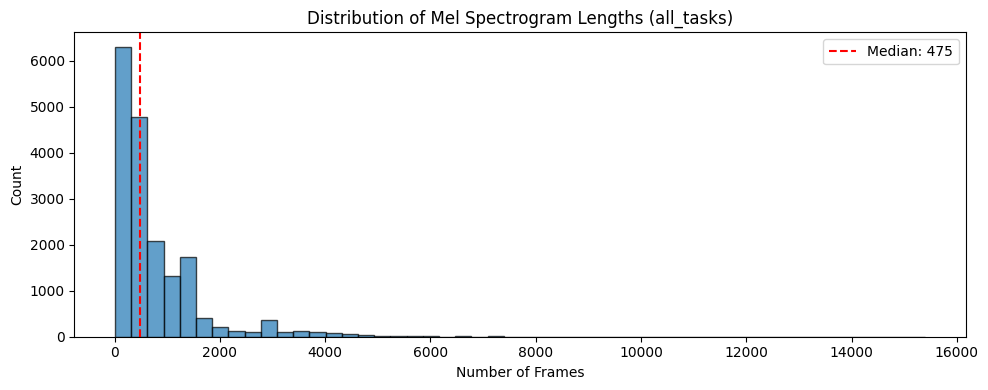

In [ ]:
# ==============================================================================
# CELL 6: Inspect spectrogram shape and statistics
# ==============================================================================

# Identify the spectrogram data column
metadata_cols = ['participant_id', 'session_id', 'task_name', 'n_frames', 'label']
spec_columns = [c for c in mel_filtered.columns if c not in metadata_cols]
print(f"Spectrogram data column(s): {spec_columns}")

# Use the first non-metadata column as the spectrogram
SPEC_COL = spec_columns[0]

# Inspect one sample
sample = mel_filtered.iloc[0]
sample_spec = np.array(sample[SPEC_COL].tolist(), dtype=np.float32)
print(f"\nSample spectrogram:")
print(f"  Shape: {sample_spec.shape}")
print(f"  dtype: {sample_spec.dtype}")
print(f"  Value range: [{sample_spec.min():.6f}, {sample_spec.max():.6f}]")

# Determine n_mels from the data
if sample_spec.ndim == 2:
    N_MELS = sample_spec.shape[0]
    print(f"  Already 2D: {N_MELS} mel bands x {sample_spec.shape[1]} frames")
elif sample_spec.ndim == 1:
    N_MELS = 60  # From dataset documentation
    n_frames_check = sample_spec.shape[0] // N_MELS
    print(f"  1D array, will reshape to {N_MELS} x {n_frames_check}")
else:
    print(f"  Unexpected ndim: {sample_spec.ndim}")

# Distribution of recording lengths
frame_lengths = mel_filtered['n_frames'].values
print(f"\nRecording length (frames):")
print(f"  Min:    {frame_lengths.min()}")
print(f"  Max:    {frame_lengths.max()}")
print(f"  Mean:   {frame_lengths.mean():.0f}")
print(f"  Median: {np.median(frame_lengths):.0f}")
print(f"  Std:    {frame_lengths.std():.0f}")

plt.figure(figsize=(10, 4))
plt.hist(frame_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Frames')
plt.ylabel('Count')
plt.title(f'Distribution of Mel Spectrogram Lengths ({TASK_FILTER})')
plt.axvline(np.median(frame_lengths), color='red', linestyle='--',
            label=f'Median: {np.median(frame_lengths):.0f}')
plt.legend()
plt.tight_layout()
plt.show()


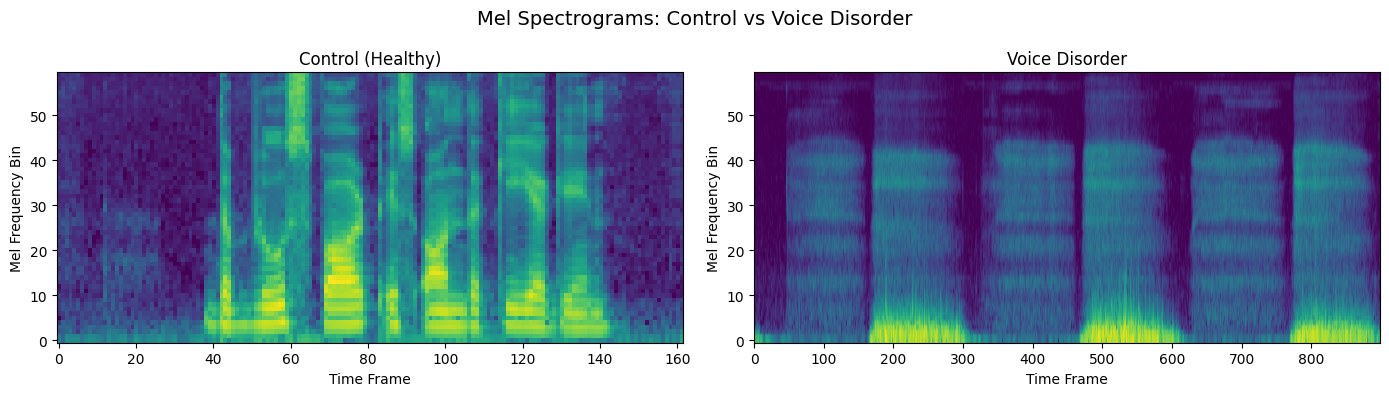

In [ ]:
# ==============================================================================
# CELL 7: Visualize sample spectrograms (Control vs Disorder)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, label_val, title in [(axes[0], 0, 'Control (Healthy)'),
                              (axes[1], 1, 'Voice Disorder')]:
    sample_row = mel_filtered[mel_filtered['label'] == label_val].iloc[0]
    spec = np.array(sample_row[SPEC_COL].tolist(), dtype=np.float32)
    if spec.ndim == 1:
        spec = spec.reshape(N_MELS, -1)

    img = librosa.power_to_db(spec + 1e-10, ref=np.max)
    ax.imshow(img, aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Time Frame')
    ax.set_ylabel('Mel Frequency Bin')

plt.suptitle('Mel Spectrograms: Control vs Voice Disorder', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CELL 8: Preprocessing functions
# ==============================================================================

# Choose fixed time length based on data distribution
TARGET_FRAMES = int(np.median(frame_lengths))
print(f"Target frame length (median): {TARGET_FRAMES}")
print(f"  This means recordings shorter than {TARGET_FRAMES} frames get zero-padded,")
print(f"  and longer ones get center-cropped.")


def preprocess_spectrogram(spec_data, target_frames=TARGET_FRAMES, n_mels=N_MELS):
    """
    Preprocess a mel spectrogram for CNN input:
    1. Reshape if needed (1D -> 2D)
    2. Convert to log scale (dB) - compresses dynamic range
    3. Pad or center-crop to fixed length
    4. Normalize to zero mean, unit variance
    """
    spec = np.array(spec_data.tolist(), dtype=np.float32)

    if spec.ndim == 1:
        spec = spec.reshape(n_mels, -1)

    # Convert to decibels - this is critical for CNNs
    # Raw power values span huge ranges; log scale makes patterns visible
    spec = librosa.power_to_db(spec + 1e-10, ref=np.max)

    # Pad or center-crop time dimension
    T = spec.shape[1]
    if T < target_frames:
        pad_width = target_frames - T
        spec = np.pad(spec, ((0, 0), (0, pad_width)),
                      mode='constant', constant_values=spec.min())
    elif T > target_frames:
        start = (T - target_frames) // 2
        spec = spec[:, start:start + target_frames]

    # Normalize
    mean, std = spec.mean(), spec.std()
    if std > 0:
        spec = (spec - mean) / std

    return spec


class VoiceDataset(Dataset):
    """PyTorch Dataset wrapping preprocessed mel spectrograms."""

    def __init__(self, spectrograms, labels):
        self.spectrograms = spectrograms
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # (n_mels, T) -> (1, n_mels, T)  [single channel "image"]
        spec = torch.FloatTensor(self.spectrograms[idx]).unsqueeze(0)
        label = torch.FloatTensor([self.labels[idx]])
        return spec, label


Target frame length (median): 475
  This means recordings shorter than 475 frames get zero-padded,
  and longer ones get center-cropped.


In [ ]:
# ==============================================================================
# CELL 9: Preprocess all spectrograms
# ==============================================================================

print("Preprocessing spectrograms...")
all_specs = []
all_labels = []
all_pids = []
errors = 0

for idx, row in mel_filtered.iterrows():
    try:
        spec = preprocess_spectrogram(row[SPEC_COL])
        all_specs.append(spec)
        all_labels.append(int(row['label']))
        all_pids.append(row['participant_id'])
    except Exception as e:
        errors += 1
        if errors <= 5:
            print(f"  Error at index {idx}: {e}")

print(f"Preprocessed: {len(all_specs)} spectrograms ({errors} errors)")
print(f"Shape per spectrogram: {all_specs[0].shape}")

# Free the big dataframe
del mel_df, mel_filtered
gc.collect()

Preprocessing spectrograms...
Preprocessed: 18029 spectrograms (0 errors)
Shape per spectrogram: (60, 475)


11550

In [ ]:

# ==============================================================================
# CELL 10: Train/Val/Test split BY PARTICIPANT
# ==============================================================================
# CRITICAL: Your original project split by participant groups using a custom
# function (train_test_split_groups). We replicate the same approach here.
#
# NOTE: Our original split function had NO random seed (a bug), meaning you can't
# reproduce the exact same test set. For this project, we set a seed so
# results are reproducible.

np.random.seed(42)  # For reproducibility (your original didn't have this!)

# Build participant -> label mapping
pid_labels = {}
for pid, label in zip(all_pids, all_labels):
    pid_labels[pid] = label

unique_pids = list(set(all_pids))
unique_labels = [pid_labels[pid] for pid in unique_pids]

print(f"Unique participants: {len(unique_pids)}")
print(f"  Disorder (1): {sum(l == 1 for l in unique_labels)}")
print(f"  Control  (0): {sum(l == 0 for l in unique_labels)}")

# --- Replicating our original split strategy ---
# Your original code: picked ~15% of groups, balanced between classes
n_test_groups = int(len(unique_pids) * 0.15)

# Separate participants by class
pids_class1 = [pid for pid, l in pid_labels.items() if l == 1 and pid in set(all_pids)]
pids_class0 = [pid for pid, l in pid_labels.items() if l == 0 and pid in set(all_pids)]

# Sample equal number from each class for test set
n_per_class = n_test_groups // 2
test_pids_1 = list(np.random.choice(pids_class1, n_per_class, replace=False))
test_pids_0 = list(np.random.choice(pids_class0, n_per_class, replace=False))
test_pids = set(test_pids_1 + test_pids_0)
train_val_pids = set(unique_pids) - test_pids

# Further split train_val into train and validation (for early stopping)
# ~15% of remaining for validation
train_val_list = list(train_val_pids)
np.random.shuffle(train_val_list)

tv_class1 = [p for p in train_val_list if pid_labels[p] == 1]
tv_class0 = [p for p in train_val_list if pid_labels[p] == 0]
n_val_per_class = max(1, int(len(train_val_list) * 0.15) // 2)
val_pids_1 = tv_class1[:n_val_per_class]
val_pids_0 = tv_class0[:n_val_per_class]
val_pids = set(val_pids_1 + val_pids_0)
train_pids = train_val_pids - val_pids

# Assign recordings to splits
train_specs, train_labels = [], []
val_specs, val_labels = [], []
test_specs, test_labels = [], []

for spec, label, pid in zip(all_specs, all_labels, all_pids):
    if pid in test_pids:
        test_specs.append(spec)
        test_labels.append(label)
    elif pid in val_pids:
        val_specs.append(spec)
        val_labels.append(label)
    else:
        train_specs.append(spec)
        train_labels.append(label)

print(f"\nSplit sizes (by recording):")
print(f"  Train: {len(train_labels):5d}  (disorder: {sum(train_labels):4d}, control: {len(train_labels)-sum(train_labels):4d})")
print(f"  Val:   {len(val_labels):5d}  (disorder: {sum(val_labels):4d}, control: {len(val_labels)-sum(val_labels):4d})")
print(f"  Test:  {len(test_labels):5d}  (disorder: {sum(test_labels):4d}, control: {len(test_labels)-sum(test_labels):4d})")
print(f"\nSplit sizes (by participant):")
print(f"  Train: {len(train_pids):4d}  Val: {len(val_pids):4d}  Test: {len(test_pids):4d}")

Unique participants: 570
  Disorder (1): 424
  Control  (0): 146

Split sizes (by recording):
  Train: 13093  (disorder: 10890, control: 2203)
  Val:    2229  (disorder: 1155, control: 1074)
  Test:   2707  (disorder: 1311, control: 1396)

Split sizes (by participant):
  Train:  414  Val:   72  Test:   84


In [ ]:
# ==============================================================================
# CELL 11: Create DataLoaders
# ==============================================================================

BATCH_SIZE = 32

# Weighted random sampling to handle class imbalance
train_counts = Counter(train_labels)
class_weights = {cls: len(train_labels) / count for cls, count in train_counts.items()}
sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_dataset = VoiceDataset(train_specs, train_labels)
val_dataset = VoiceDataset(val_specs, val_labels)
test_dataset = VoiceDataset(test_specs, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Verify
batch_x, batch_y = next(iter(train_loader))
print(f"Batch shape: {batch_x.shape}")  # Expected: (32, 1, N_MELS, TARGET_FRAMES)
print(f"Label shape: {batch_y.shape}")

Batch shape: torch.Size([32, 1, 60, 475])
Label shape: torch.Size([32, 1])


In [ ]:
# ==============================================================================
# CELL 12: Define CNN Model
# ==============================================================================

class VoiceCNN(nn.Module):
    """
    Simple 3-block CNN for mel spectrogram binary classification.

    Architecture rationale:
    - 3 conv blocks is standard for small-to-medium image tasks
    - BatchNorm stabilizes training and allows higher learning rates
    - AdaptiveAvgPool removes dependence on exact input size
    - Dropout (0.5) in the classifier prevents overfitting on small datasets

    This is a BASELINE architecture. For the final report, you could try:
    - Deeper networks (ResNet-18 pretrained on ImageNet, fine-tuned)
    - Adding data augmentation (time/frequency masking aka SpecAugment)
    - Multi-task learning (predict multiple disorder types)
    """

    def __init__(self, n_mels=60):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: detect basic spectral patterns
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2: combine into higher-level patterns
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3: disorder-specific signatures
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),  # -> (batch, 128, 1, 1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1),  # single output, use BCEWithLogitsLoss
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = VoiceCNN(n_mels=N_MELS).to(device)

# Model summary
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(model)

# Sanity check
with torch.no_grad():
    dummy = torch.randn(2, 1, N_MELS, TARGET_FRAMES).to(device)
    out = model(dummy)
    print(f"Forward pass OK. Output shape: {out.shape}")

Model parameters: 101,441
VoiceCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=128

In [ ]:
# ==============================================================================
# CELL 13: Training and evaluation functions
# ==============================================================================

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for specs, labels in loader:
        specs, labels = specs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(specs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * specs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    return total_loss / len(loader.dataset), f1_score(all_labels, all_preds, average='weighted')


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_probs, all_labels = [], [], []

    for specs, labels in loader:
        specs, labels = specs.to(device), labels.to(device)
        outputs = model(specs)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * specs.size(0)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return loss, f1, all_preds, all_probs, all_labels


In [ ]:
# ==============================================================================
# CELL 14: Train the model
# ==============================================================================

# Hyperparameters — reasonable defaults, no tuning needed for intermediate report
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Training history
history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}

# Early stopping
best_val_f1 = 0
patience = 10
patience_counter = 0
best_model_state = None

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train F1':>9} | {'Val Loss':>10} | {'Val F1':>9} | {'LR':>10}")
print("-" * 68)

for epoch in range(NUM_EPOCHS):
    train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_f1, _, _, _ = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    scheduler.step(val_loss)
    lr = optimizer.param_groups[0]['lr']

    print(f"{epoch+1:5d} | {train_loss:10.4f} | {train_f1:9.4f} | {val_loss:10.4f} | {val_f1:9.4f} | {lr:10.6f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}. Best val F1: {best_val_f1:.4f}")
            break

if best_model_state:
    model.load_state_dict(best_model_state)
print(f"\nBest validation F1: {best_val_f1:.4f}")

Epoch | Train Loss |  Train F1 |   Val Loss |    Val F1 |         LR
--------------------------------------------------------------------
    1 |     0.6739 |    0.5767 |     0.7168 |    0.4694 |   0.001000
    2 |     0.6404 |    0.6328 |     0.6999 |    0.5224 |   0.001000
    3 |     0.6231 |    0.6526 |     0.6599 |    0.5983 |   0.001000
    4 |     0.6092 |    0.6699 |     0.6848 |    0.5905 |   0.001000
    5 |     0.6055 |    0.6710 |     0.7210 |    0.5394 |   0.001000
    6 |     0.5942 |    0.6813 |     0.6157 |    0.6675 |   0.001000
    7 |     0.5866 |    0.6833 |     0.6164 |    0.6574 |   0.001000
    8 |     0.5867 |    0.6858 |     0.7216 |    0.5670 |   0.001000
    9 |     0.5753 |    0.6963 |     0.7256 |    0.5614 |   0.001000
   10 |     0.5704 |    0.7013 |     0.7500 |    0.5566 |   0.001000
   11 |     0.5631 |    0.7102 |     0.6468 |    0.6127 |   0.001000
   12 |     0.5649 |    0.7105 |     0.6051 |    0.6932 |   0.001000
   13 |     0.5544 |    0.7151 |  

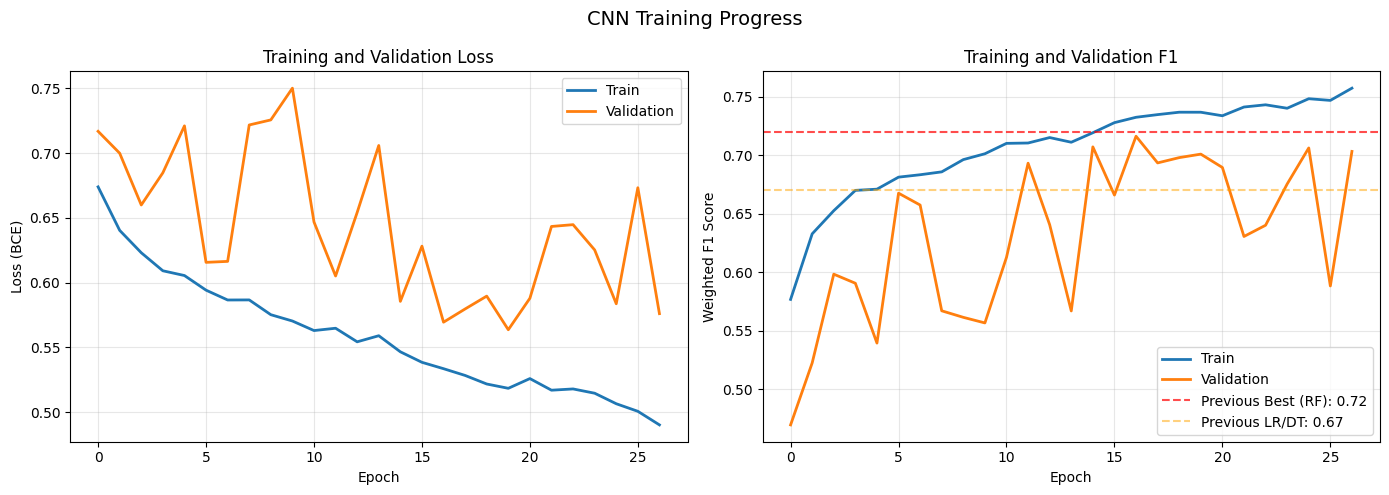

In [ ]:
# ==============================================================================
# CELL 15: Training curves
# ==============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train', linewidth=2)
ax1.plot(history['val_loss'], label='Validation', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (BCE)')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_f1'], label='Train', linewidth=2)
ax2.plot(history['val_f1'], label='Validation', linewidth=2)
ax2.axhline(y=0.72, color='red', linestyle='--', alpha=0.7,
            label='Previous Best (RF): 0.72')
ax2.axhline(y=0.67, color='orange', linestyle='--', alpha=0.5,
            label='Previous LR/DT: 0.67')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Weighted F1 Score')
ax2.set_title('Training and Validation F1')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('CNN Training Progress', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:

# ==============================================================================
# CELL 16: Test set evaluation
# ==============================================================================

test_loss, test_f1, test_preds, test_probs, test_labels_out = evaluate(
    model, test_loader, criterion
)

print("=" * 55)
print("  TEST SET RESULTS")
print("=" * 55)
print(f"  Loss:           {test_loss:.4f}")
print(f"  Weighted F1:    {test_f1:.4f}")
print(f"  Accuracy:       {accuracy_score(test_labels_out, test_preds):.4f}")
print(f"  Precision:      {precision_score(test_labels_out, test_preds, zero_division=0):.4f}")
print(f"  Recall:         {recall_score(test_labels_out, test_preds, zero_division=0):.4f}")

try:
    auc = roc_auc_score(test_labels_out, test_probs)
    print(f"  AUC-ROC:        {auc:.4f}")
except ValueError:
    auc = None
    print("  AUC-ROC:        N/A (single class in test set)")

print(f"\n  Previous ML Baselines:")
print(f"    Logistic Regression:  0.67")
print(f"    Decision Tree:        0.67")
print(f"    Random Forest:        0.72  <-- best")
print(f"  CNN (this model):       {test_f1:.4f}")

if test_f1 > 0.72:
    print("\n  >>> CNN outperforms all previous baselines!")
elif test_f1 > 0.67:
    print("\n  >>> CNN outperforms LR and DT but not Random Forest.")
else:
    print("\n  >>> CNN does not yet outperform baselines. See discussion.")

print("\nClassification Report:")
print(classification_report(test_labels_out, test_preds,
                            target_names=['Control', 'Voice Disorder']))


  TEST SET RESULTS
  Loss:           0.6018
  Weighted F1:    0.6645
  Accuracy:       0.6649
  Precision:      0.6380
  Recall:         0.7124
  AUC-ROC:        0.7443

  Previous ML Baselines:
    Logistic Regression:  0.67
    Decision Tree:        0.67
    Random Forest:        0.72  <-- best
  CNN (this model):       0.6645

  >>> CNN does not yet outperform baselines. See discussion.

Classification Report:
                precision    recall  f1-score   support

       Control       0.70      0.62      0.66      1396
Voice Disorder       0.64      0.71      0.67      1311

      accuracy                           0.66      2707
     macro avg       0.67      0.67      0.66      2707
  weighted avg       0.67      0.66      0.66      2707



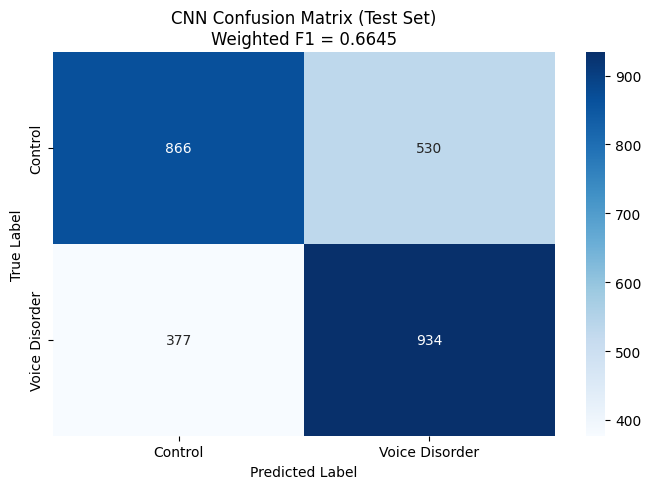

In [ ]:
# ==============================================================================
# CELL 17: Confusion matrix
# ==============================================================================

cm = confusion_matrix(test_labels_out, test_preds)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Control', 'Voice Disorder'],
            yticklabels=['Control', 'Voice Disorder'], ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title(f'CNN Confusion Matrix (Test Set)\nWeighted F1 = {test_f1:.4f}')
plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# CELL 18: Model comparison table
# ==============================================================================

# These are the actual numbers from your AML Final Deliverable
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression (static features)',
        'Decision Tree (static features)',
        'Random Forest (static features)',
        f'CNN (mel spectrogram, {TASK_FILTER})',
    ],
    'Feature Type': ['Static Acoustic', 'Static Acoustic', 'Static Acoustic', 'Mel Spectrogram'],
    'Train F1': [0.67, 0.68, 0.64, history['train_f1'][-1]],
    'Val F1': [0.66, 0.65, 0.62, best_val_f1],
    'Test F1': [0.67, 0.67, 0.72, test_f1],
})

print("\n" + "=" * 80)
print("MODEL COMPARISON (from AML Final Deliverable + this CNN)")
print("=" * 80)
print(comparison.to_string(index=False))
print("\nNote: Previous baselines used static acoustic features (96 features per recording).")
print("CNN uses mel spectrograms (60 mel bands x time, treated as images).")
print(f"CNN task filter: {TASK_FILTER}")


MODEL COMPARISON (from AML Final Deliverable + this CNN)
                                Model    Feature Type  Train F1   Val F1  Test F1
Logistic Regression (static features) Static Acoustic  0.670000 0.660000 0.670000
      Decision Tree (static features) Static Acoustic  0.680000 0.650000 0.670000
      Random Forest (static features) Static Acoustic  0.640000 0.620000 0.720000
     CNN (mel spectrogram, all_tasks) Mel Spectrogram  0.757351 0.716244 0.664467

Note: Previous baselines used static acoustic features (96 features per recording).
CNN uses mel spectrograms (60 mel bands x time, treated as images).
CNN task filter: all_tasks


In [ ]:
# ==============================================================================
# CELL 19: Save checkpoint
# ==============================================================================

save_dir = os.path.join(DATA_DIR, 'models')
os.makedirs(save_dir, exist_ok=True)

checkpoint_path = os.path.join(save_dir, 'voice_cnn_checkpoint.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'history': history,
    'test_f1': test_f1,
    'best_val_f1': best_val_f1,
    'config': {
        'n_mels': N_MELS,
        'target_frames': TARGET_FRAMES,
        'batch_size': BATCH_SIZE,
        'lr': LEARNING_RATE,
        'task_filter': TASK_FILTER,
    },
    'test_pids': list(test_pids),
    'val_pids': list(val_pids),
}, checkpoint_path)
print(f"Checkpoint saved to: {checkpoint_path}")

Checkpoint saved to: /content/drive/MyDrive/ML 4 Health Project/data/models/voice_cnn_checkpoint.pth


## Optimizations for final report... we'll be using a specAugment and the Fusion model Wenxin recommended

In [ ]:
# ==============================================================================
# CELL 20: SpecAugment Data Augmentation
# ==============================================================================
# SpecAugment randomly masks blocks of time and frequency during training.
# This forces the CNN to not rely on any single region of the spectrogram,
# dramatically reducing overfitting. It's the standard augmentation for
# audio CNNs (Park et al., 2019).

import torch
import torch.nn as nn

class SpecAugment(nn.Module):
    """
    Apply SpecAugment to mel spectrograms during training.
    Randomly masks contiguous blocks along time and frequency axes.
    """
    def __init__(self, freq_mask_param=10, time_mask_param=40, n_freq_masks=2, n_time_masks=2):
        super().__init__()
        self.freq_mask_param = freq_mask_param   # max width of frequency mask
        self.time_mask_param = time_mask_param   # max width of time mask
        self.n_freq_masks = n_freq_masks         # number of frequency masks
        self.n_time_masks = n_time_masks         # number of time masks

    def forward(self, x):
        if not self.training:
            return x  # no augmentation at eval time

        x = x.clone()
        _, _, n_mels, n_frames = x.shape

        # Apply frequency masks
        for _ in range(self.n_freq_masks):
            f = torch.randint(0, min(self.freq_mask_param, n_mels), (1,)).item()
            f0 = torch.randint(0, max(1, n_mels - f), (1,)).item()
            x[:, :, f0:f0+f, :] = 0

        # Apply time masks
        for _ in range(self.n_time_masks):
            t = torch.randint(0, min(self.time_mask_param, n_frames), (1,)).item()
            t0 = torch.randint(0, max(1, n_frames - t), (1,)).item()
            x[:, :, :, t0:t0+t] = 0

        return x

print("SpecAugment defined.")
print("  - Masks up to 10 mel bands (of 60) and up to 40 time frames (of 475)")
print("  - Applied 2x each per spectrogram, only during training")

SpecAugment defined.
  - Masks up to 10 mel bands (of 60) and up to 40 time frames (of 475)
  - Applied 2x each per spectrogram, only during training


In [ ]:
# ==============================================================================
# CELL 21: Improved CNN with SpecAugment built in
# ==============================================================================

class VoiceCNN_v2(nn.Module):
    """
    Improved CNN with SpecAugment and same architecture as v1.
    Changes from v1:
      - SpecAugment applied to input during training
      - Everything else identical for controlled comparison
    """
    def __init__(self, n_mels=60):
        super().__init__()

        self.augment = SpecAugment(
            freq_mask_param=10,   # mask up to 10 of 60 mel bands (~17%)
            time_mask_param=40,   # mask up to 40 of 475 frames (~8%)
            n_freq_masks=2,
            n_time_masks=2
        )

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.augment(x)  # only active during training
        x = self.features(x)
        return self.classifier(x)

    def extract_features(self, x):
        """Return the 128-dim embedding before the classifier (for fusion)."""
        x = self.features(x)
        return x.view(x.size(0), -1)  # (batch, 128)


model_v2 = VoiceCNN_v2(n_mels=N_MELS).to(device)
print(f"VoiceCNN_v2 parameters: {sum(p.numel() for p in model_v2.parameters()):,}")
print("Changes: + SpecAugment on input during training")

VoiceCNN_v2 parameters: 101,441
Changes: + SpecAugment on input during training


Cell 22

Trains CNN v2 with SpecAugment + learning rate of 3e-4 (instead of 1e-3). Same data, same split, same everything else. This is a controlled experiment: two changes, both targeting overfitting.

In [ ]:
# ==============================================================================
# CELL 22: Re-train with SpecAugment + lower learning rate
# ==============================================================================

from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from collections import Counter

# Re-create data loaders (same data, same split — already in memory)
BATCH_SIZE = 32

train_counts = Counter(train_labels)
class_weights_dict = {cls: len(train_labels) / count for cls, count in train_counts.items()}
sample_weights = [class_weights_dict[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# KEY CHANGE: Lower learning rate (3e-4 instead of 1e-3). This is to address the overfitting we saw in v1
LEARNING_RATE_V2 = 3e-4
NUM_EPOCHS_V2 = 80 # raising this so model has longer to learn. We are introducing corrupted data.

criterion = nn.BCEWithLogitsLoss()
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=LEARNING_RATE_V2, weight_decay=1e-4)
scheduler_v2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_v2, mode='min', factor=0.5, patience=5)

# Training history
history_v2 = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}

best_val_f1_v2 = 0
patience_counter_v2 = 0
best_model_state_v2 = None

print(f"Training CNN v2 (SpecAugment + lr={LEARNING_RATE_V2})")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train F1':>9} | {'Val Loss':>10} | {'Val F1':>9} | {'LR':>10}")
print("-" * 68)

for epoch in range(NUM_EPOCHS_V2):
    # Train
    model_v2.train()
    total_loss = 0
    all_preds_t, all_labels_t = [], []
    for specs, labels in train_loader:
        specs, labels = specs.to(device), labels.to(device)
        optimizer_v2.zero_grad()
        outputs = model_v2(specs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_v2.step()
        total_loss += loss.item() * specs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        all_preds_t.extend(preds.cpu().numpy().flatten())
        all_labels_t.extend(labels.cpu().numpy().flatten())
    train_loss = total_loss / len(train_loader.dataset)
    train_f1 = f1_score(all_labels_t, all_preds_t, average='weighted')

    # Validate
    model_v2.eval()
    total_loss_v = 0
    all_preds_v, all_probs_v, all_labels_v = [], [], []
    with torch.no_grad():
        for specs, labels in val_loader:
            specs, labels = specs.to(device), labels.to(device)
            outputs = model_v2(specs)
            loss = criterion(outputs, labels)
            total_loss_v += loss.item() * specs.size(0)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            all_preds_v.extend(preds.cpu().numpy().flatten())
            all_probs_v.extend(probs.cpu().numpy().flatten())
            all_labels_v.extend(labels.cpu().numpy().flatten())
    val_loss = total_loss_v / len(val_loader.dataset)
    val_f1 = f1_score(all_labels_v, all_preds_v, average='weighted')

    history_v2['train_loss'].append(train_loss)
    history_v2['train_f1'].append(train_f1)
    history_v2['val_loss'].append(val_loss)
    history_v2['val_f1'].append(val_f1)

    scheduler_v2.step(val_loss)
    lr = optimizer_v2.param_groups[0]['lr']
    print(f"{epoch+1:5d} | {train_loss:10.4f} | {train_f1:9.4f} | {val_loss:10.4f} | {val_f1:9.4f} | {lr:10.6f}")

    if val_f1 > best_val_f1_v2:
        best_val_f1_v2 = val_f1
        patience_counter_v2 = 0
        best_model_state_v2 = {k: v.clone() for k, v in model_v2.state_dict().items()}
    else:
        patience_counter_v2 += 1
        if patience_counter_v2 >= 25:
            print(f"\nEarly stopping at epoch {epoch+1}. Best val F1: {best_val_f1_v2:.4f}")
            break

if best_model_state_v2:
    model_v2.load_state_dict(best_model_state_v2)
print(f"\nBest validation F1: {best_val_f1_v2:.4f} (v1 was {best_val_f1:.4f})")

Training CNN v2 (SpecAugment + lr=0.0003)
Epoch | Train Loss |  Train F1 |   Val Loss |    Val F1 |         LR
--------------------------------------------------------------------
    1 |     0.6181 |    0.6601 |     0.7492 |    0.4980 |   0.000300
    2 |     0.6183 |    0.6561 |     0.6292 |    0.6518 |   0.000300
    3 |     0.6102 |    0.6697 |     0.6337 |    0.6700 |   0.000300
    4 |     0.6093 |    0.6727 |     0.6658 |    0.6035 |   0.000300
    5 |     0.6025 |    0.6728 |     0.6706 |    0.5699 |   0.000300
    6 |     0.6047 |    0.6699 |     0.6533 |    0.6369 |   0.000300
    7 |     0.6033 |    0.6773 |     0.7693 |    0.5441 |   0.000300
    8 |     0.6042 |    0.6726 |     0.6336 |    0.6466 |   0.000150
    9 |     0.5902 |    0.6871 |     0.6059 |    0.6957 |   0.000150
   10 |     0.5904 |    0.6839 |     0.7281 |    0.5435 |   0.000150
   11 |     0.5935 |    0.6828 |     0.6113 |    0.6662 |   0.000150
   12 |     0.5797 |    0.6916 |     0.6125 |    0.6868 |   0

  CNN v2 TEST RESULTS (SpecAugment + lr=3e-4)
  Weighted F1:  0.6736  (v1: 0.7456)
  Accuracy:     0.6742
  AUC-ROC:      0.7548

Classification Report:
                precision    recall  f1-score   support

       Control       0.71      0.62      0.66      1396
Voice Disorder       0.65      0.73      0.68      1311

      accuracy                           0.67      2707
     macro avg       0.68      0.68      0.67      2707
  weighted avg       0.68      0.67      0.67      2707



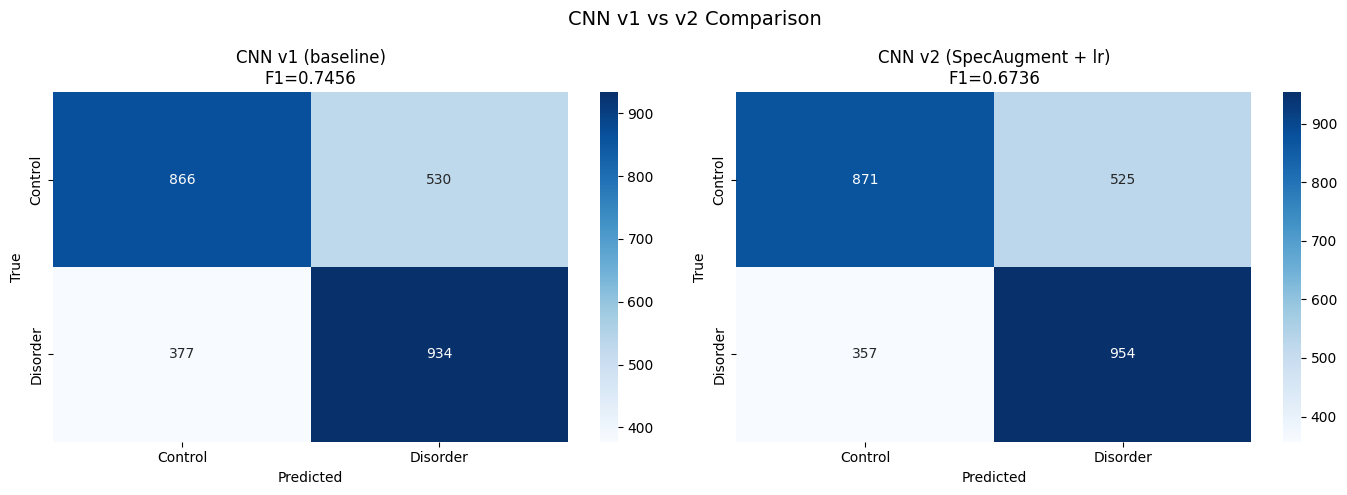

In [ ]:
# ==============================================================================
# CELL 23: Evaluate CNN v2 on test set
# ==============================================================================

model_v2.eval()
all_preds_test, all_probs_test, all_labels_test = [], [], []
with torch.no_grad():
    for specs, labels in test_loader:
        specs, labels = specs.to(device), labels.to(device)
        outputs = model_v2(specs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        all_preds_test.extend(preds.cpu().numpy().flatten())
        all_probs_test.extend(probs.cpu().numpy().flatten())
        all_labels_test.extend(labels.cpu().numpy().flatten())

test_f1_v2 = f1_score(all_labels_test, all_preds_test, average='weighted')
test_acc_v2 = accuracy_score(all_labels_test, all_preds_test)
test_auc_v2 = roc_auc_score(all_labels_test, all_probs_test)

print("=" * 60)
print("  CNN v2 TEST RESULTS (SpecAugment + lr=3e-4)")
print("=" * 60)
print(f"  Weighted F1:  {test_f1_v2:.4f}  (v1: {test_f1:.4f})")
print(f"  Accuracy:     {test_acc_v2:.4f}")
print(f"  AUC-ROC:      {test_auc_v2:.4f}")
print(f"\nClassification Report:")
print(classification_report(all_labels_test, all_preds_test,
                            target_names=['Control', 'Voice Disorder']))

# Confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels_test, all_preds_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, cm_data, f1_val) in zip(axes, [
    (f'CNN v1 (baseline)\nF1={test_f1:.4f}', confusion_matrix(test_labels, [int(p) for p in test_preds]), test_f1),
    (f'CNN v2 (SpecAugment + lr)\nF1={test_f1_v2:.4f}', cm, test_f1_v2),
]):
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Control', 'Disorder'],
                yticklabels=['Control', 'Disorder'], ax=ax)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
    ax.set_title(title)
plt.suptitle('CNN v1 vs v2 Comparison', fontsize=14)
plt.tight_layout()
plt.show()


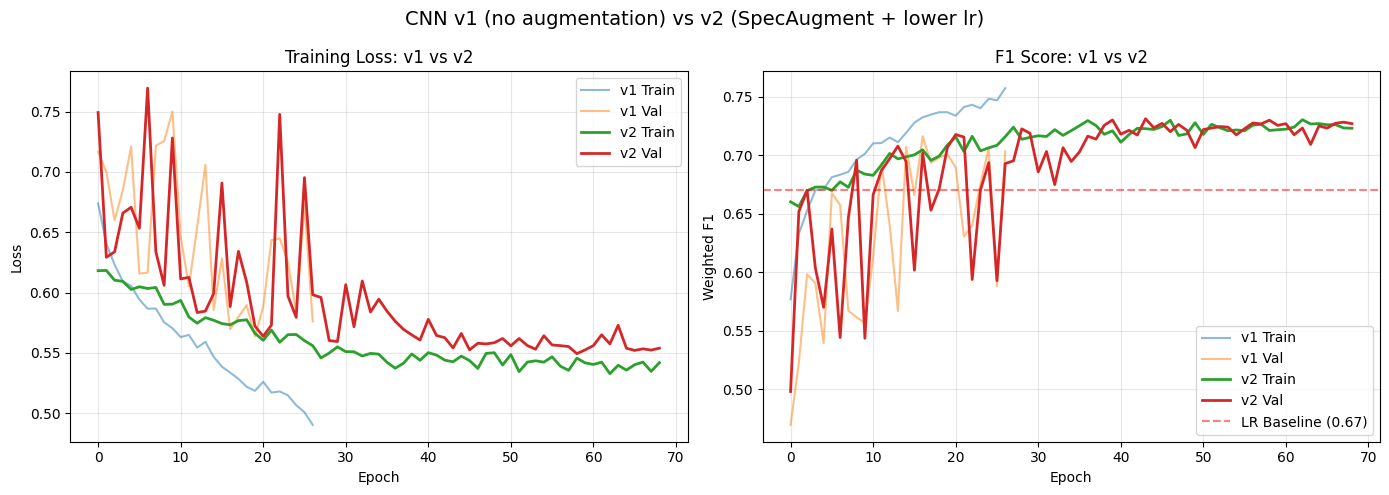

In [ ]:
# ==============================================================================
# CELL 24: Training curves comparison
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='v1 Train', alpha=0.5)
axes[0].plot(history['val_loss'], label='v1 Val', alpha=0.5)
axes[0].plot(history_v2['train_loss'], label='v2 Train', linewidth=2)
axes[0].plot(history_v2['val_loss'], label='v2 Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss: v1 vs v2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1
axes[1].plot(history['train_f1'], label='v1 Train', alpha=0.5)
axes[1].plot(history['val_f1'], label='v1 Val', alpha=0.5)
axes[1].plot(history_v2['train_f1'], label='v2 Train', linewidth=2)
axes[1].plot(history_v2['val_f1'], label='v2 Val', linewidth=2)
axes[1].axhline(y=0.67, color='red', linestyle='--', alpha=0.5, label='LR Baseline (0.67)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Weighted F1')
axes[1].set_title('F1 Score: v1 vs v2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN v1 (no augmentation) vs v2 (SpecAugment + lower lr)', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# CELL 25: Extract CNN embeddings for fusion model
# ==============================================================================
# The fusion model combines CNN-learned features (128-dim) with
# static acoustic features (96-dim) into a single 224-dim vector.

import pandas as pd

test_f1_v1 = test_f1  # save before the loop overwrites it

print("Extracting CNN v2 embeddings for all recordings...")

model_v2.eval()
embeddings = {'participant_id': [], 'session_id': [], 'embedding': [], 'label': [], 'split': []}

# We need session_id to merge with static features.
# Rebuild the mapping from the original mel_filtered dataframe.
# Since mel_filtered was deleted, we need to reload just the IDs.

# Reload mel spectrogram metadata (just IDs, not the heavy spectrogram column)
mel_meta = pd.read_parquet(mel_path, columns=['participant_id', 'session_id', 'task_name'])
mel_meta['participant_id'] = mel_meta['participant_id'].astype(str).str.zfill(6)
mel_meta_labeled = mel_meta[mel_meta['participant_id'].isin(participant_label_map)].copy()
print(f"Mel metadata: {len(mel_meta_labeled)} recordings")

# We'll extract embeddings from the already-preprocessed spectrograms
# using the same ordering as all_specs/all_labels/all_pids
def extract_embeddings(model, specs_list, batch_size=64):
    """Extract 128-dim embeddings from the CNN feature extractor."""
    model.eval()
    all_emb = []
    for i in range(0, len(specs_list), batch_size):
        batch = torch.FloatTensor(np.stack(specs_list[i:i+batch_size])).unsqueeze(1).to(device)
        with torch.no_grad():
            emb = model.extract_features(batch)
        all_emb.append(emb.cpu().numpy())
    return np.concatenate(all_emb, axis=0)

all_embeddings = extract_embeddings(model_v2, all_specs)
print(f"Extracted embeddings: {all_embeddings.shape}")  # Should be (18029, 128)

# Assign splits
all_splits = []
for pid in all_pids:
    if pid in test_pids:
        all_splits.append('test')
    elif pid in val_pids:
        all_splits.append('val')
    else:
        all_splits.append('train')

emb_df = pd.DataFrame(all_embeddings, columns=[f'cnn_emb_{i}' for i in range(128)])
emb_df['participant_id'] = all_pids
emb_df['label'] = all_labels
emb_df['split'] = all_splits

print(f"Embedding dataframe: {emb_df.shape}")
print(f"  Train: {sum(emb_df['split']=='train')}")
print(f"  Val:   {sum(emb_df['split']=='val')}")
print(f"  Test:  {sum(emb_df['split']=='test')}")


Extracting CNN v2 embeddings for all recordings...
Mel metadata: 18029 recordings
Extracted embeddings: (18029, 128)
Embedding dataframe: (18029, 131)
  Train: 13093
  Val:   2229
  Test:  2707


In [ ]:
# ==============================================================================
# CELL 26: Load static features and merge with CNN embeddings
# ==============================================================================

# Load static features (same path as baselines notebook)
sf_path = None
for candidate in [
    os.path.join(DATA_DIR, 'features', 'static_features.tsv'),
    os.path.join(DATA_DIR, 'static_features.tsv'),
]:
    if os.path.exists(candidate):
        sf_path = candidate
        break

print(f"Loading static features from: {sf_path}")
static_df = pd.read_csv(sf_path, sep='\t')
static_df['participant_id'] = static_df['participant_id'].astype(str).str.zfill(6)

# Filter to labeled participants
static_df = static_df[static_df['participant_id'].isin(participant_label_map)].copy()

# Get feature columns (same cleaning as baselines notebook)
meta_cols_sf = ['participant_id', 'session_id', 'task_name']
feature_cols = [c for c in static_df.columns if c not in meta_cols_sf
                and pd.api.types.is_numeric_dtype(static_df[c])]
nan_counts = static_df[feature_cols].isna().sum()
high_nan = nan_counts[nan_counts > 50].index.tolist()
feature_cols = [c for c in feature_cols if c not in high_nan]
static_clean = static_df[meta_cols_sf + feature_cols].dropna()

print(f"Static features: {len(static_clean)} recordings, {len(feature_cols)} features")

# The challenge: CNN embeddings and static features are per-recording but
# there's no session_id in our preprocessed data. We need to merge by
# participant_id + recording index within each participant.
#
# Simpler approach: average both embeddings and static features per participant,
# then merge at participant level. This also prevents the model from memorizing
# per-recording patterns.

print("\nAveraging features per participant...")

# Average CNN embeddings per participant
emb_cols = [f'cnn_emb_{i}' for i in range(128)]
emb_avg = emb_df.groupby(['participant_id', 'split'])[emb_cols + ['label']].mean().reset_index()
emb_avg['label'] = emb_avg['label'].round().astype(int)

# Average static features per participant
static_clean['label'] = static_clean['participant_id'].map(participant_label_map)
static_avg = static_clean.groupby('participant_id')[feature_cols].mean().reset_index()

# Merge on participant_id
fusion_df = emb_avg.merge(static_avg, on='participant_id', how='inner')
print(f"Fusion dataset: {fusion_df.shape[0]} participants, {len(emb_cols) + len(feature_cols)} features")
print(f"  CNN embedding dims: {len(emb_cols)}")
print(f"  Static feature dims: {len(feature_cols)}")
print(f"  Total: {len(emb_cols) + len(feature_cols)}")


Loading static features from: /content/drive/MyDrive/ML 4 Health Project/data/features/static_features.tsv
Static features: 20141 recordings, 96 features

Averaging features per participant...
Fusion dataset: 570 participants, 224 features
  CNN embedding dims: 128
  Static feature dims: 96
  Total: 224


In [ ]:

# ==============================================================================
# CELL 27: Train and evaluate fusion model
# ==============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Split using the same participant assignments
fusion_train = fusion_df[fusion_df['split'] == 'train']
fusion_val = fusion_df[fusion_df['split'] == 'val']
fusion_test = fusion_df[fusion_df['split'] == 'test']

all_feature_cols = emb_cols + feature_cols

X_train_fusion = fusion_train[all_feature_cols].values
y_train_fusion = fusion_train['label'].values
X_val_fusion = fusion_val[all_feature_cols].values
y_val_fusion = fusion_val['label'].values
X_test_fusion = fusion_test[all_feature_cols].values
y_test_fusion = fusion_test['label'].values

print(f"Fusion splits:")
print(f"  Train: {len(X_train_fusion)} participants")
print(f"  Val:   {len(X_val_fusion)} participants")
print(f"  Test:  {len(X_test_fusion)} participants")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fusion)
X_val_scaled = scaler.transform(X_val_fusion)
X_test_scaled = scaler.transform(X_test_fusion)

# Train logistic regression on fusion features
# Also train on CNN-only and static-only for ablation
results = {}

configs = {
    'Static only (LR, per-participant)': (feature_cols, 'Per-participant averaged static features'),
    'CNN embedding only (LR)': (emb_cols, 'Per-participant averaged CNN embeddings'),
    'Fusion: CNN + Static (LR)': (all_feature_cols, 'CNN embeddings + static features combined'),
}

for name, (cols, desc) in configs.items():
    col_idx = [all_feature_cols.index(c) for c in cols]
    Xtr = X_train_scaled[:, col_idx]
    Xval = X_val_scaled[:, col_idx]
    Xte = X_test_scaled[:, col_idx]

    lr = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42, C=1.0)
    lr.fit(Xtr, y_train_fusion)

    val_f1 = f1_score(y_val_fusion, lr.predict(Xval), average='weighted')
    test_f1 = f1_score(y_test_fusion, lr.predict(Xte), average='weighted')
    test_acc = accuracy_score(y_test_fusion, lr.predict(Xte))

    results[name] = {'val_f1': val_f1, 'test_f1': test_f1, 'accuracy': test_acc, 'n_features': len(cols)}
    print(f"\n{name} ({len(cols)} features):")
    print(f"  Val F1:  {val_f1:.4f}")
    print(f"  Test F1: {test_f1:.4f}")
    print(f"  Acc:     {test_acc:.4f}")


Fusion splits:
  Train: 414 participants
  Val:   72 participants
  Test:  84 participants

Static only (LR, per-participant) (96 features):
  Val F1:  0.7214
  Test F1: 0.7969
  Acc:     0.7976

CNN embedding only (LR) (128 features):
  Val F1:  0.8194
  Test F1: 0.7258
  Acc:     0.7262

Fusion: CNN + Static (LR) (224 features):
  Val F1:  0.7319
  Test F1: 0.6860
  Acc:     0.6905


In [ ]:
# ==============================================================================
# CELL 28: Full comparison table
# ==============================================================================

print("\n" + "=" * 80)
print("COMPLETE MODEL COMPARISON — Bridge2AI-Voice v3.0.0")
print("=" * 80)

comparison = pd.DataFrame([
    {'Model': 'Logistic Regression (static, per-recording)', 'Features': '96 static', 'Test F1': 0.6694, 'Level': 'Recording'},
    {'Model': 'Decision Tree (static, per-recording)', 'Features': '96 static', 'Test F1': 0.6390, 'Level': 'Recording'},
    {'Model': 'Random Forest (static, per-recording)', 'Features': '96 static', 'Test F1': 0.6337, 'Level': 'Recording'},
    {'Model': 'CNN v1 (baseline)', 'Features': '60×475 mel spec', 'Test F1': test_f1_v1, 'Level': 'Recording'},
    {'Model': 'CNN v2 (SpecAugment + lr)', 'Features': '60×475 mel spec', 'Test F1': test_f1_v2, 'Level': 'Recording'},
    {'Model': 'Static only (LR, per-participant)', 'Features': f'{len(feature_cols)} static', 'Test F1': results['Static only (LR, per-participant)']['test_f1'], 'Level': 'Participant'},
    {'Model': 'CNN embedding only (LR)', 'Features': '128 CNN emb', 'Test F1': results['CNN embedding only (LR)']['test_f1'], 'Level': 'Participant'},
    {'Model': 'Fusion: CNN + Static (LR)', 'Features': f'{len(all_feature_cols)} combined', 'Test F1': results['Fusion: CNN + Static (LR)']['test_f1'], 'Level': 'Participant'},
])

print(comparison.to_string(index=False))
print("\nNote: Per-recording models predict per voice sample; per-participant models")
print("average features per participant first. Same test participants across all models.")



COMPLETE MODEL COMPARISON — Bridge2AI-Voice v3.0.0
                                      Model        Features  Test F1       Level
Logistic Regression (static, per-recording)       96 static 0.669400   Recording
      Decision Tree (static, per-recording)       96 static 0.639000   Recording
      Random Forest (static, per-recording)       96 static 0.633700   Recording
                          CNN v1 (baseline) 60×475 mel spec 0.745638   Recording
                  CNN v2 (SpecAugment + lr) 60×475 mel spec 0.673557   Recording
          Static only (LR, per-participant)       96 static 0.796899 Participant
                    CNN embedding only (LR)     128 CNN emb 0.725841 Participant
                  Fusion: CNN + Static (LR)    224 combined 0.686026 Participant

Note: Per-recording models predict per voice sample; per-participant models
average features per participant first. Same test participants across all models.


In [ ]:
# ==============================================================================
# CELL 29: Save CNN v2 checkpoint
# ==============================================================================

save_dir = os.path.join(DATA_DIR, 'models')
os.makedirs(save_dir, exist_ok=True)

checkpoint_path_v2 = os.path.join(save_dir, 'voice_cnn_v2_checkpoint.pth')
torch.save({
    'model_state_dict': model_v2.state_dict(),
    'history': history_v2,
    'test_f1': test_f1_v2,
    'best_val_f1': best_val_f1_v2,
    'config': {
        'n_mels': N_MELS,
        'target_frames': TARGET_FRAMES,
        'batch_size': BATCH_SIZE,
        'lr': LEARNING_RATE_V2,
        'specaugment': True,
    },
    'fusion_results': results,
}, checkpoint_path_v2)
print(f"CNN v2 checkpoint saved to: {checkpoint_path_v2}")


CNN v2 checkpoint saved to: /content/drive/MyDrive/ML 4 Health Project/data/models/voice_cnn_v2_checkpoint.pth
